# PARTE 1 — EDA con pandas API de PySpark

## 1- Cargar los datos

In [1]:
import pyspark.pandas as ps

df = ps.read_csv("insurance.csv")

C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(
C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\utils.py:1038: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


### Primeras filas

In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Información general

In [3]:
df.info()

<class 'pyspark.pandas.frame.DataFrame'>
Index: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int32  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int32  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int32(2), object(3)

## 2- Limpieza de datos y valores nulos

### Valores nulos

In [4]:
print(df.isnull().sum())

C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\generic.py:1373: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  warnings.warn(


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


#### No se encontraron valores nulos en el dataset, por lo tanto no fue necesario aplicar técnicas de imputación o eliminación de registros.

## 3- Exploración univariante

### Variables categóricas

In [5]:
print(df['sex'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64


In [6]:
print(df['smoker'].value_counts())

smoker
no     1064
yes     274
Name: count, dtype: int64


In [7]:
print(df['region'].value_counts())

region
southeast    364
northwest    325
southwest    325
northeast    324
Name: count, dtype: int64


#### Hay un número similar de hombres y mujeres, La mayoría de las personas no fuma y Las regiones están relativamente equilibradas

### Variables numéricas

In [8]:
print(df[['age', 'bmi', 'children', 'charges']].describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4738.268200
50%      39.000000    30.400000     1.000000   9377.904700
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


#### Edad y Bmi: La media es de 39 años y el bmo promedio es de 30.6.

#### Hijos: La gran mayoría de las personas tiene uno o ningún hijo.

#### Cargos: Los costos médicos están muy dispersos, con una mediana de 9,378 y un máximo de 63,770.

## 4- Exploración bivariante

### smoker y charges

In [9]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

#### los fumadores generalmente conllevan cargos médicos mucho más elevados.

### Age y charges

In [10]:
df.groupby('age')['charges'].mean()

age
31    10196.980573
53    16020.930755
34    11613.528121
28     9069.187564
27    12184.701721
26     6133.825309
44    15859.396587
22    10012.932802
47    17653.999593
52    18256.269719
40    11772.251310
20    10159.697736
57    16447.185250
54    18758.546475
48    14632.500445
19     9747.909335
64    23275.530837
41     9653.745650
43    19267.278653
37    18019.911877
61    22024.457609
35    11307.182031
59    18895.869532
55    16164.545488
23    12419.820040
39    11778.242945
49    12696.006264
51    15682.255867
63    19884.998461
50    15663.003301
45    14830.199856
38     8102.733674
25     9838.365311
24    10648.015962
62    19163.856573
29    10430.158727
21     4730.464330
32     9220.300291
60    21979.418507
56    15025.515837
58    13878.928112
33    12351.532987
42    13061.038669
30    12719.110358
46    14342.590639
18     7086.217556
36    12204.476138
Name: charges, dtype: float64

#### los adultos mayores suelen presentar gastos médicos más elevados.

In [11]:
print(
    df[['age', 'bmi', 'children', 'charges']].corr()
)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


#### La edad es la variable con mayor correlación positiva con los costes médicos (~0.30), seguida por el bmi (~0.20).por otro lado, el número de hijos no muestra una relación significativa con los cargos (~0.07).

# visualizaciones

### 1.Histograma de charges

C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas Series is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


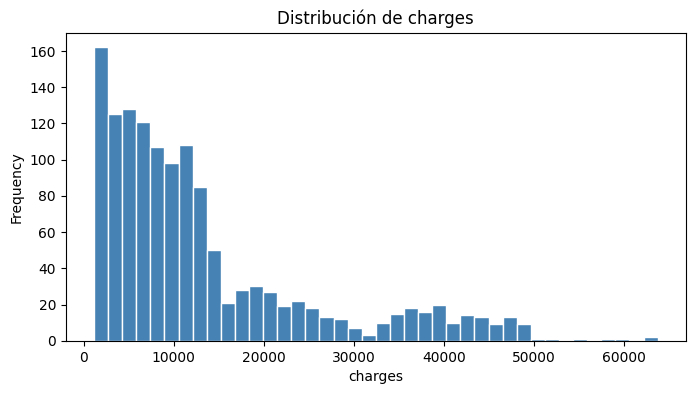

In [12]:
import matplotlib
import matplotlib.pyplot as plt

# Histograma de charges
df['charges'].to_pandas().plot(
    kind='hist', bins=40, title='Distribución de charges',
    figsize=(8, 4), color='steelblue', edgecolor='white'
)
plt.xlabel('charges')
plt.show()

#### La mayoría de los asegurados pagan costes bajos, pero hay una cola larga de costes muy elevados

### 2.Boxplot charges por smoker

C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


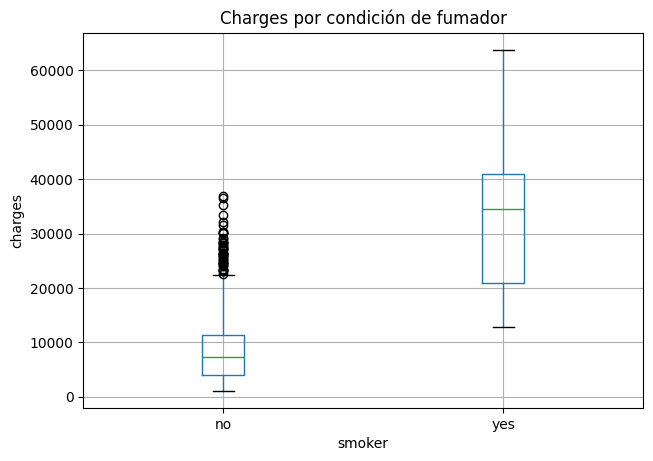

In [13]:
df[['charges', 'smoker']].to_pandas().boxplot(
    column='charges', by='smoker', figsize=(7, 5)
)
plt.title('Charges por condición de fumador')
plt.suptitle('')
plt.ylabel('charges')
plt.show()

#### Los fumadores tienen una mediana de costes ~3x superior a los no fumadores

### 3. Scatter age vs charges

C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\utils.py:1038: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


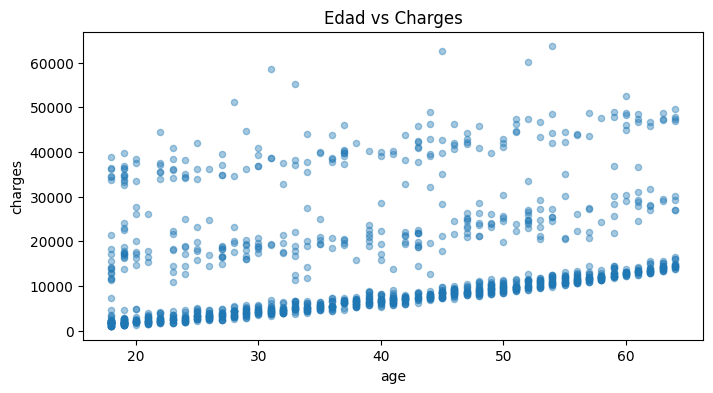

In [14]:
df[['age', 'charges']].to_pandas().plot(
    kind='scatter', x='age', y='charges',
    alpha=0.4, figsize=(8, 4), title='Edad vs Charges'
)
plt.show()

#### Se aprecian tres bandas de costes según la edad, probablemente relacionadas con el hábito tabáquico

# Conclusiones del EDA:

No se encontraron valores ausentes (nulos).

El conjunto de datos contiene variables tanto categóricas como numéricas.

Los fumadores tienen un fuerte impacto en los costes médicos.

La edad también influye en los costes del seguro.

# PARTE 2 — MACHINE LEARNING

### 1- Convertir a Spark DataFrame

In [28]:
spark_df = df.to_spark()
spark_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: integer (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)



C:\Users\PC\anaconda3\envs\pyspark_env\lib\site-packages\pyspark\pandas\utils.py:1038: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


### 2-Importar librerías de ML

In [16]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

### 3- Convertir variables categóricas

In [17]:
sex_indexer = StringIndexer(
    inputCol='sex',
    outputCol='sex_index'
)

smoker_indexer = StringIndexer(
    inputCol='smoker',
    outputCol='smoker_index'
)

region_indexer = StringIndexer(
    inputCol='region',
    outputCol='region_index'
)

### 4- Crear columna de features

In [18]:
assembler = VectorAssembler(
    inputCols=[
        'age',
        'bmi',
        'children',
        'sex_index',
        'smoker_index',
        'region_index'
    ],
    outputCol='unscaled_features'
)

### 5- Escalar variables

In [19]:
scaler = StandardScaler(
    inputCol='unscaled_features',
    outputCol='features',
    withMean=True,
    withStd=True
)

### 6- Crear modelo

In [20]:
lr = LinearRegression(
    featuresCol='features',
    labelCol='charges'
)

### 7- Crear pipeline

In [21]:
pipeline = Pipeline(stages=[
    sex_indexer,
    smoker_indexer,
    region_indexer,
    assembler,
    scaler,
    lr
])

### 8- Separar train/test

In [22]:
train_data, test_data = spark_df.randomSplit([0.7, 0.3], seed=100)

### 9- Entrenar modelo

In [23]:
model = pipeline.fit(train_data)

### 10- Realizar predicciones

In [24]:
predictions = model.transform(test_data)

### 11- Ver resultados

In [25]:
predictions.select(
    'charges',
    'prediction'
).show(10)

+-----------+------------------+
|    charges|        prediction|
+-----------+------------------+
|  2196.4732| 971.8554735571779|
| 21344.8467|2558.7303877763225|
| 2203.73595| 2618.612460011009|
|  4561.1885| 4471.174305976996|
|  2205.9808| 3127.610074005828|
| 2211.13075| 4295.310482582179|
|  1629.8335|  3814.12249941717|
|14133.03775| 4264.813885183481|
| 2217.46915|5732.4802162146125|
| 12829.4551|22799.644964180065|
+-----------+------------------+
only showing top 10 rows


### 12- Evaluar modelo

In [26]:
evaluator = RegressionEvaluator(
    labelCol='charges',
    predictionCol='prediction',
    metricName='rmse'
)

rmse = evaluator.evaluate(predictions)

print("RMSE:", rmse)

RMSE: 6548.402012237414


# Conclusión

#### El modelo de regresión lineal se entrenó correctamente utilizando las variables del dataset para predecir los costos médicos (charges). Se obtuvo un RMSE de 6548, lo que indica que el modelo tiene un error medio aproximado de 6548. Aunque algunas predicciones presentan diferencias respecto a los valores reales, el modelo logra capturar la tendencia general de los datos y constituye una solución válida para este problema de regresión. Además, durante el análisis se observó que la variable smoker es probablemente la más influyente, ya que las personas fumadoras presentan costos médicos significativamente más altos que las no fumadoras.